# Bank Marketing Campaign Predictor using a Decision Tree Classifier
In this project, we will use demographic and behavioral client data to predict whether a customer will subscribe to a bank term deposit (indicated by the variable `y`).

In [1]:
# Import data manipulation and visualization tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the full dataset 
df = pd.read_csv('bank-full.csv', sep=';')

# Display the first 5 rows to ensure everything looks correct
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Check data column profiles and check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
# 1. Map our target outcome 'y' from ('yes', 'no') to binary integers (1, 0)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 2. Split data into features (independent variables X) and the target variable (y)
X = df.drop(columns=['y'])
y = df['y']

# 3. Convert text columns (like job, education, marital status) to dummy variables using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Original number of feature columns: {X.shape[1]}")
print(f"Expanded columns after One-Hot Encoding: {X_encoded.shape[1]}")

Original number of feature columns: 16
Expanded columns after One-Hot Encoding: 42


In [5]:
# Stratify keeps the proportion of subscribers equal in both groups
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training Set Samples: {X_train.shape[0]}")
print(f"Testing Set Samples: {X_test.shape[0]}")

Training Set Samples: 31647
Testing Set Samples: 13564


In [6]:
# Initialize the Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model with the training subset
model.fit(X_train, y_train)

print("The Decision Tree has been successfully trained!")

The Decision Tree has been successfully trained!


In [7]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Prediction Accuracy: {accuracy:.2%}\n")

# Detailed metrics report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Overall Prediction Accuracy: 90.03%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95     11977
           1       0.66      0.30      0.41      1587

    accuracy                           0.90     13564
   macro avg       0.79      0.64      0.68     13564
weighted avg       0.88      0.90      0.88     13564



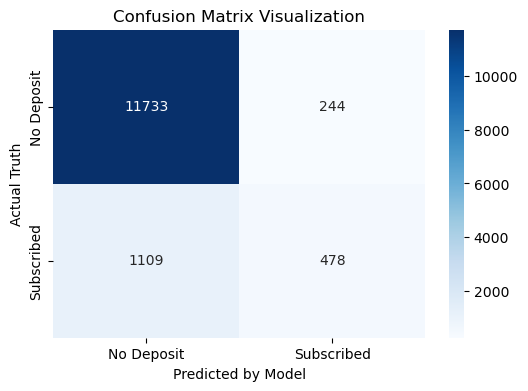

In [8]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create heatmap visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Deposit', 'Subscribed'], yticklabels=['No Deposit', 'Subscribed'])
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Truth')
plt.title('Confusion Matrix Visualization')
plt.show()

In [9]:
# Extract feature importance values
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 5 Most Influential Predictive Factors:")
for i in range(5):
    print(f"{i+1}. {X_encoded.columns[indices[i]]}: ({importances[indices[i]] * 100:.2f}%)")

Top 5 Most Influential Predictive Factors:
1. duration: (56.11%)
2. poutcome_success: (28.59%)
3. housing_yes: (4.23%)
4. age: (2.50%)
5. pdays: (2.10%)


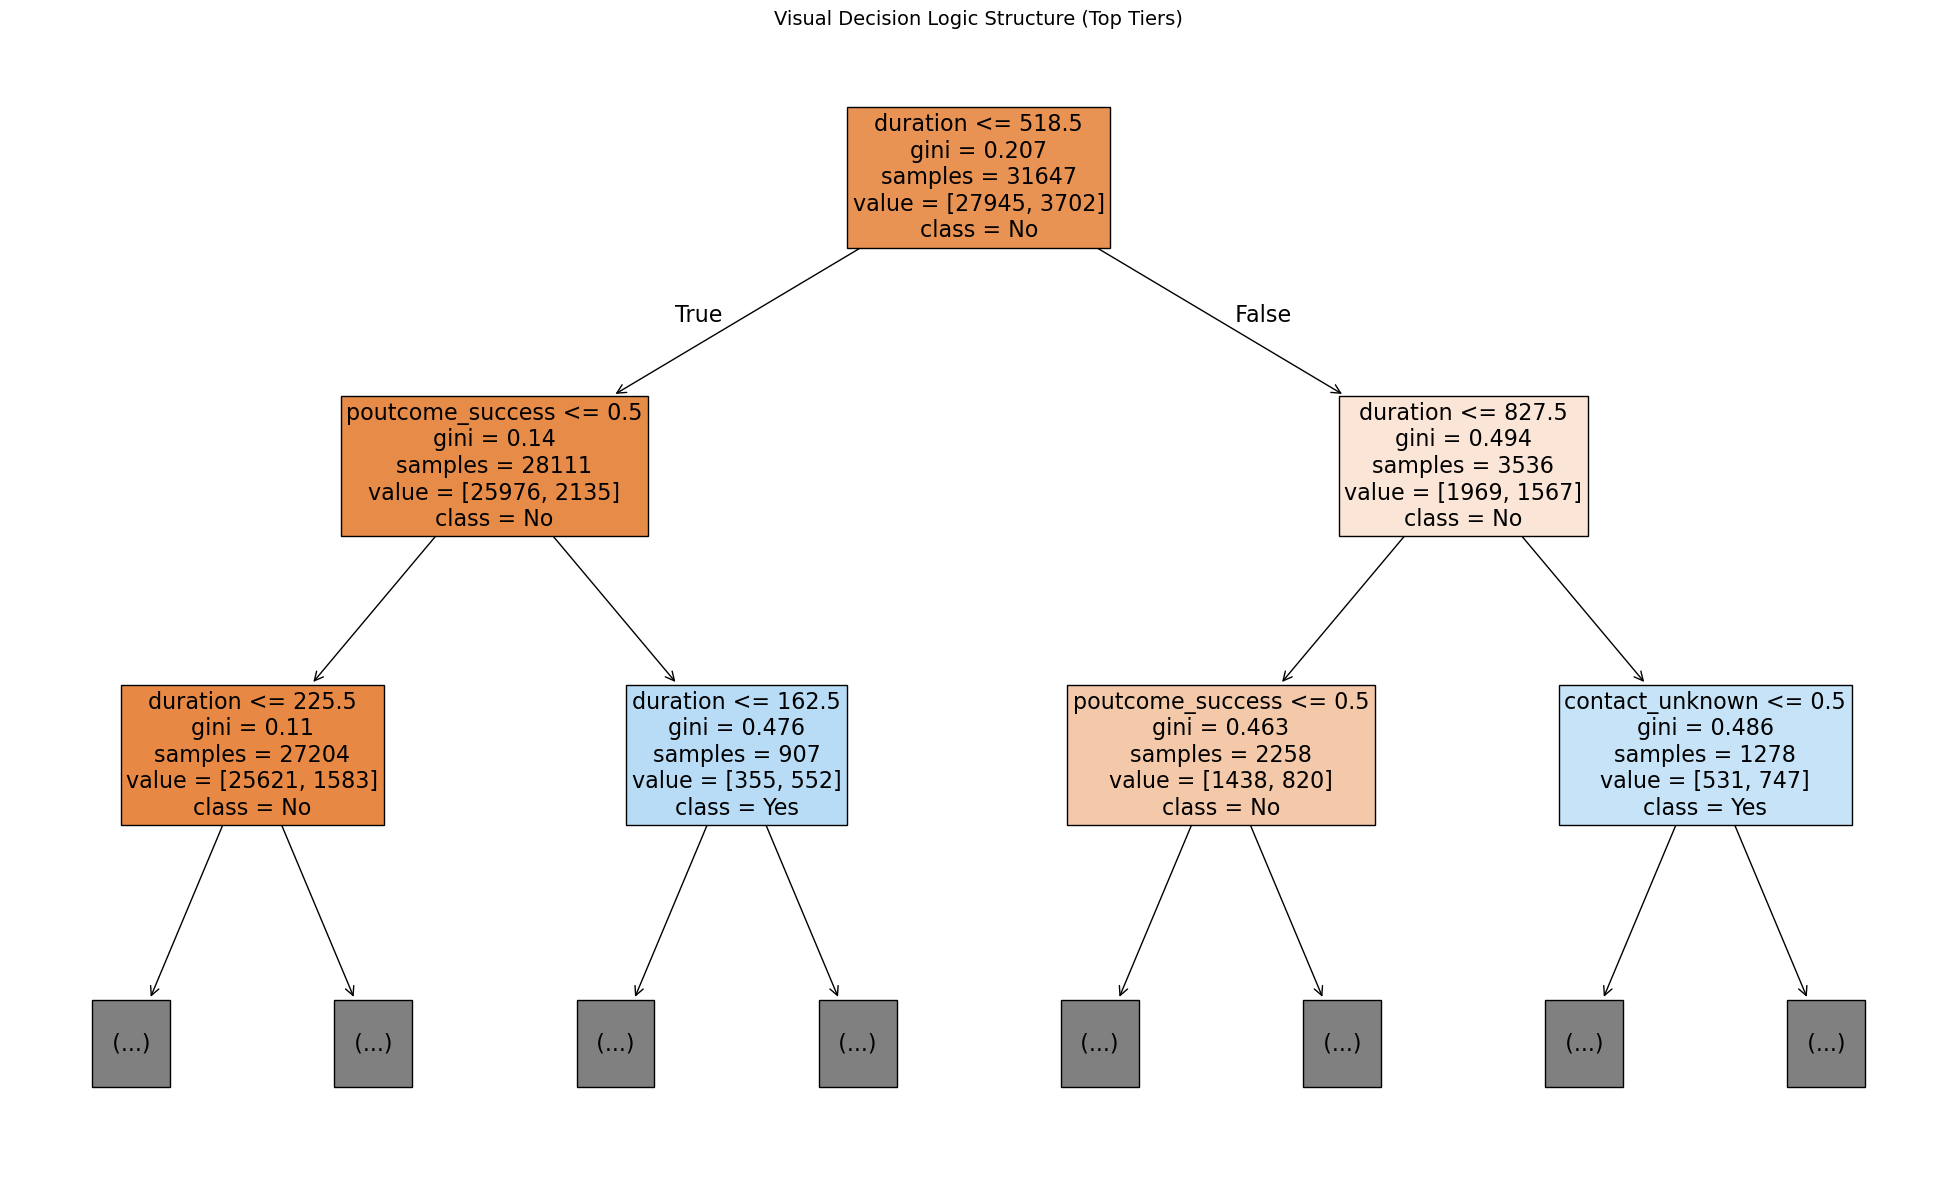

In [12]:
# Plotting the rules up to the first two levels
plt.figure(figsize=(25, 15))
plot_tree(model, max_depth=2, feature_names=list(X_encoded.columns), class_names=['No', 'Yes'], filled=True, fontsize=16)
plt.title("Visual Decision Logic Structure (Top Tiers)", fontsize=14)
plt.show()